# CAD Detection: predicting coronary artery disease from clinical data

Group project, re-run with a corrected, leak-free evaluation.

> **Disclaimer:** educational project only. It is not a medical tool and must not be used for diagnosis.

**Dataset:** [heart.csv on Kaggle](https://www.kaggle.com/datasets/arezaei81/heartcsv) (303 patients, 13 clinical features and a binary `target`). Put `heart.csv` next to this notebook, or upload it when running in Colab.

**What this notebook does**
1. Loads the data and checks for missing values and duplicate rows.
2. Explores a few features.
3. Splits the data once: 70% training, 30% held-out test.
4. Runs 10-fold cross-validation on the **training set only**, then scores each model **once** on the test set.
5. Compares five classifiers, each with an ensemble method.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

SEED = 1
DATA_PATH = "heart.csv"

# Colab only: ask for the file if it is not there yet (does nothing on a normal computer)
try:
    from google.colab import files
    if not Path(DATA_PATH).exists():
        files.upload()
except ImportError:
    pass

## 1. Load and check the data

In [2]:
data = pd.read_csv(DATA_PATH)
print("Shape:", data.shape)
print("Missing values:", int(data.isnull().sum().sum()))
print("Duplicate rows:", int(data.duplicated().sum()))
data.head()

Shape: (303, 14)
Missing values: 0
Duplicate rows: 1


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Duplicate rows are a problem for evaluation: if the same patient row lands in both the training and test sets, the model is scored on something it has already seen. So duplicates are dropped before splitting.

In [3]:
data = data.drop_duplicates().reset_index(drop=True)
print("Rows after dropping duplicates:", len(data))
print()
print("Class balance (target):")
print(data["target"].value_counts().to_string())

Rows after dropping duplicates: 302

Class balance (target):
target
1    164
0    138


## 2. Quick exploration

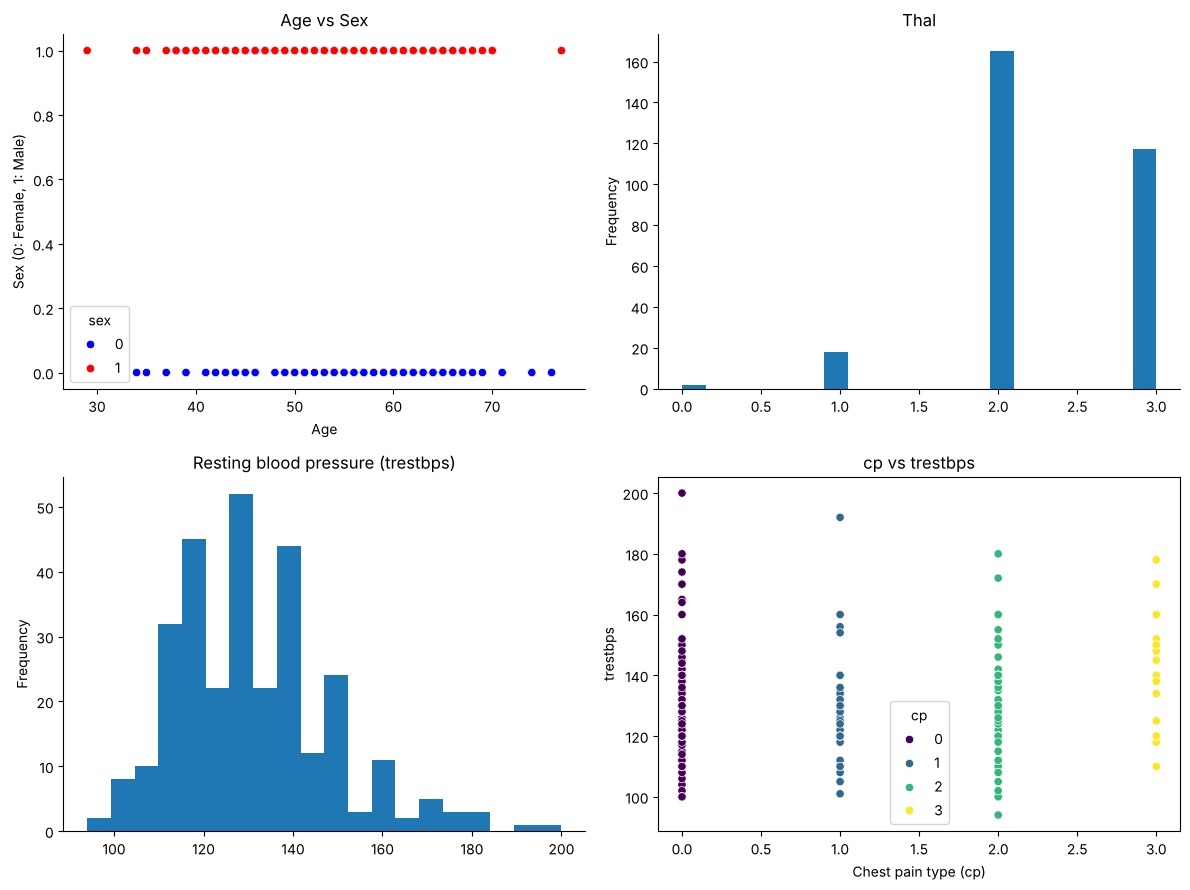

In [4]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))

ax = sns.scatterplot(x="age", y="sex", data=data, ax=axes[0, 0], hue="sex", palette={0: "blue", 1: "red"})
ax.set(xlabel="Age", ylabel="Sex (0: Female, 1: Male)", title="Age vs Sex")
ax.spines[["top", "right"]].set_visible(False)

data["thal"].plot(kind="hist", bins=20, title="Thal", ax=axes[0, 1])
axes[0, 1].spines[["top", "right"]].set_visible(False)

data["trestbps"].plot(kind="hist", bins=20, title="Resting blood pressure (trestbps)", ax=axes[1, 0])
axes[1, 0].spines[["top", "right"]].set_visible(False)

ax = sns.scatterplot(x="cp", y="trestbps", data=data, ax=axes[1, 1], hue="cp", palette="viridis")
ax.set(xlabel="Chest pain type (cp)", ylabel="trestbps", title="cp vs trestbps")

plt.tight_layout()
plt.show()

## 3. Train / test split

One stratified split, made before any model sees the data. The test set is touched only once per model, at the end.

In [5]:
X = data.drop(columns="target")
y = data["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (211, 13)  Test: (91, 13)


## 4. Models

| Base model | Ensemble method |
|---|---|
| Support Vector Classifier (linear) | AdaBoost, 150 estimators |
| K-Nearest Neighbors (k = 1) | Bagging, 300 estimators |
| Decision Tree | AdaBoost, 50 estimators |
| Logistic Regression | AdaBoost, 150 estimators |
| Random Forest | AdaBoost, 150 estimators |

SVM, KNN and Logistic Regression are scale-sensitive, so they get a `StandardScaler` in front. Inside a pipeline, the scaler is fitted on each cross-validation training fold only.

In [6]:
models = {
    "SVM (linear) + AdaBoost": make_pipeline(
        StandardScaler(),
        AdaBoostClassifier(estimator=SVC(kernel="linear"), n_estimators=150, random_state=SEED),
    ),
    "KNN (k=1) + Bagging": make_pipeline(
        StandardScaler(),
        BaggingClassifier(estimator=KNeighborsClassifier(n_neighbors=1),
                          n_estimators=300, random_state=SEED, n_jobs=-1),
    ),
    "Decision Tree + AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=SEED), n_estimators=50, random_state=SEED
    ),
    "Logistic Regression + AdaBoost": make_pipeline(
        StandardScaler(),
        AdaBoostClassifier(estimator=LogisticRegression(C=1.0, max_iter=1000),
                           n_estimators=150, random_state=SEED),
    ),
    "Random Forest + AdaBoost": AdaBoostClassifier(
        estimator=RandomForestClassifier(random_state=SEED, n_jobs=-1),
        n_estimators=150, random_state=SEED
    ),
}

## 5. Evaluation

For each model:
- **10-fold stratified cross-validation on the training set**, to estimate performance and its spread.
- **One final fit on the full training set and one score on the held-out test set.**

Sensitivity is recall on the disease class (the share of real cases caught). Specificity is the share of healthy patients correctly cleared.

In [7]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
scoring = ["accuracy", "precision", "recall", "f1"]
rows, test_preds = [], {}

for name, model in models.items():
    cv_res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    test_preds[name] = pred
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    precision = tp / (tp + fp)
    sensitivity = tp / (tp + fn)
    rows.append({
        "Model": name,
        "CV accuracy": cv_res["test_accuracy"].mean(),
        "CV std": cv_res["test_accuracy"].std(),
        "Test accuracy": (tp + tn) / len(y_test),
        "Test precision": precision,
        "Test sensitivity": sensitivity,
        "Test specificity": tn / (tn + fp),
        "Test F1": 2 * precision * sensitivity / (precision + sensitivity),
    })
    print(f"done: {name}")

results = pd.DataFrame(rows).set_index("Model")
(results * 100).round(1)

done: SVM (linear) + AdaBoost


done: KNN (k=1) + Bagging
done: Decision Tree + AdaBoost


done: Logistic Regression + AdaBoost


done: Random Forest + AdaBoost


,CV accuracy,CV std,Test accuracy,Test precision,Test sensitivity,Test specificity,Test F1
Model,,,,,,,
SVM (linear) + AdaBoost,79.1,4.9,84.6,79.7,95.9,71.4,87.0
KNN (k=1) + Bagging,74.9,7.0,79.1,76.8,87.8,69.0,81.9
Decision Tree + AdaBoost,68.7,5.5,71.4,76.7,67.3,76.2,71.7
Logistic Regression + AdaBoost,77.7,6.1,85.7,81.0,95.9,73.8,87.9
Random Forest + AdaBoost,79.1,9.1,81.3,83.3,81.6,81.0,82.5


### Confusion matrices on the held-out test set

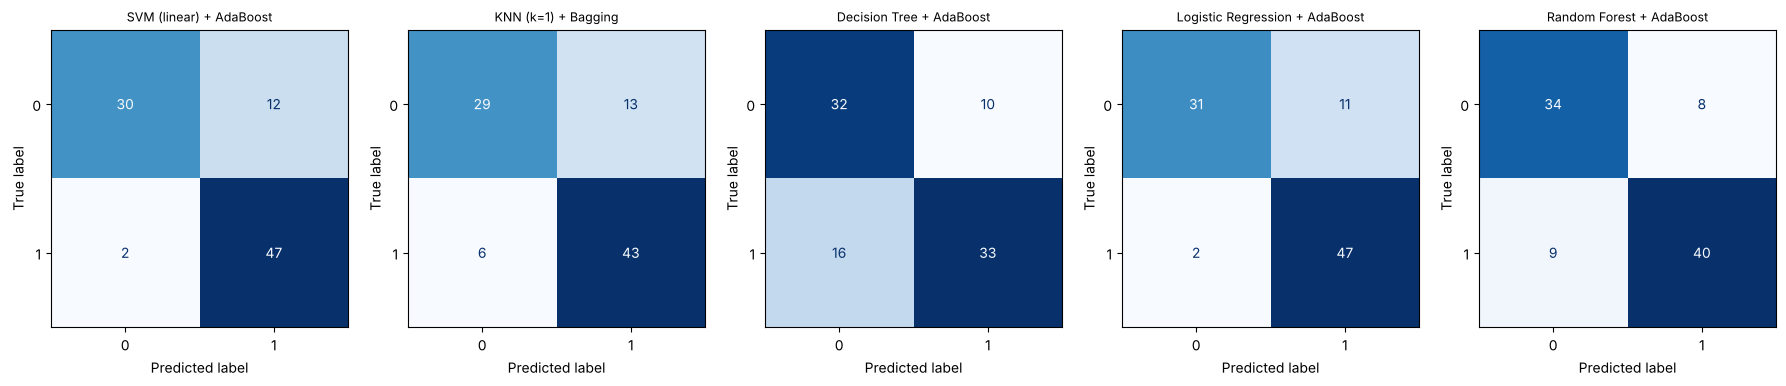

In [8]:
fig, axes = plt.subplots(1, len(test_preds), figsize=(18, 3.6))
for ax, (name, pred) in zip(axes, test_preds.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=9)
plt.tight_layout()
plt.show()

### Accuracy comparison

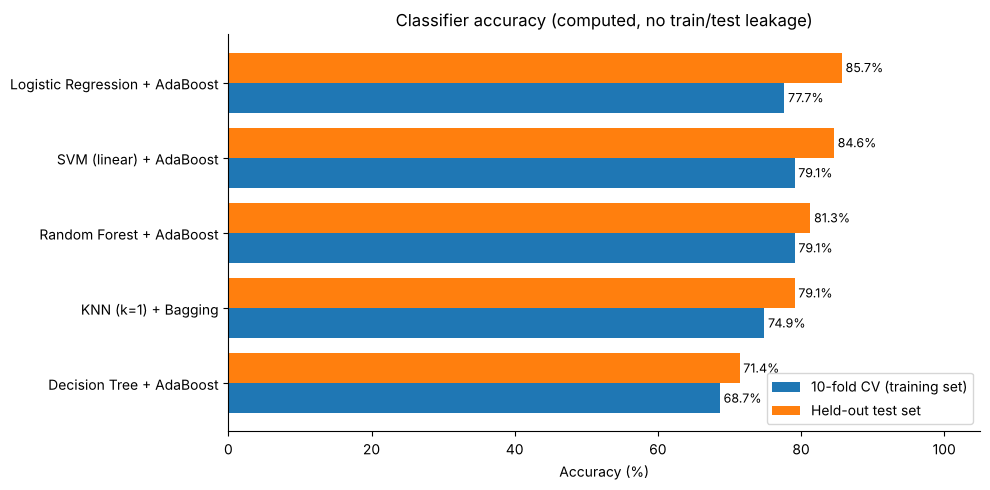

In [9]:
ordered = results.sort_values("Test accuracy")
pos = np.arange(len(ordered))
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(pos - 0.2, ordered["CV accuracy"] * 100, height=0.4, label="10-fold CV (training set)")
ax.barh(pos + 0.2, ordered["Test accuracy"] * 100, height=0.4, label="Held-out test set")
for i, (cv_a, te_a) in enumerate(zip(ordered["CV accuracy"], ordered["Test accuracy"])):
    ax.text(cv_a * 100 + 0.5, i - 0.2, f"{cv_a * 100:.1f}%", va="center", fontsize=9)
    ax.text(te_a * 100 + 0.5, i + 0.2, f"{te_a * 100:.1f}%", va="center", fontsize=9)
ax.set_yticks(pos)
ax.set_yticklabels(ordered.index)
ax.set_xlim(0, 105)
ax.set_xlabel("Accuracy (%)")
ax.set_title("Classifier accuracy (computed, no train/test leakage)")
ax.legend(loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 6. A check on the boosting

AdaBoost trains one learner at a time and stops early if a learner fits the training data perfectly. A full-depth Decision Tree and a Random Forest usually do, so let us see how many boosting rounds actually ran.

In [10]:
for name in ["Decision Tree + AdaBoost", "Random Forest + AdaBoost"]:
    ada = models[name]
    print(f"{name}: {len(ada.estimators_)} round(s) fitted (requested {ada.n_estimators})")

Decision Tree + AdaBoost: 1 round(s) fitted (requested 50)
Random Forest + AdaBoost: 1 round(s) fitted (requested 150)


## 7. Takeaways

- Held-out accuracy ranges from about 71% to 86%, and 10-fold CV accuracy from about 69% to 79%. This is a realistic range for a 300-patient clinical dataset. The 100% scores in the first version of this project came from evaluating on rows that were also used for training.
- The SVM, Logistic Regression and Random Forest models are close to each other (about 78 to 79% in cross-validation). The CV standard deviations of 5 to 9 points mean these differences are not meaningful.
- The test set has only 91 patients, so one patient changes accuracy by about 1.1 points. The CV numbers are the steadier comparison; the test-set ranking should be read loosely.
- The linear models have high sensitivity (about 96%): they catch most disease cases, at the cost of more false alarms. In a screening setting that trade-off is usually the preferred one.
- The Decision Tree and Random Forest "boosting" ran a single round (section 6), so those two rows are in effect a plain tree and a plain forest. Boosting shallow trees (stumps) would be a better set-up and is a sensible next step.
- Hyperparameters were not tuned, and the label encoding follows the Kaggle file; check it against the UCI documentation before drawing any clinical conclusion.